IMPORTS

In [32]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader,Subset
import matplotlib.pyplot as plt
import random
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

DATA PREPROCESSING

In [56]:
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),


    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1,
        saturation=0.1
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2023, 0.1994, 0.2010)
    )
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2023, 0.1994, 0.2010)
    )
])

LOADING CIFAR-10 DATASET

In [34]:
full_train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=train_transform
)

full_val_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=False,
    transform=test_transform
)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=test_transform
)

TRAIN-VALIDATION SPLIT

In [35]:
indices = list(range(len(full_train_dataset)))
random.shuffle(indices)

train_indices = indices[:45000]
val_indices = indices[45000:]

train_dataset = Subset(full_train_dataset, train_indices)
val_dataset = Subset(full_val_dataset, val_indices)

DATA LOADERS

In [36]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

VERIFY DATASET AND DATALOADER

In [37]:
images, labels = next(iter(train_loader))

print("Dataset and DataLoader are working correctly!")
print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

Dataset and DataLoader are working correctly!
Image batch shape: torch.Size([64, 3, 32, 32])
Label batch shape: torch.Size([64])


DEVICE CONFIGURATION

In [38]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

RESIDUAL BLOCK IMPLEMENTATION

In [39]:
class ResidualBlock(nn.Module):

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                stride=stride,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(out_channels)
        )

        self.shortcut = nn.Sequential()

        if stride != 1 or in_channels != out_channels:

            self.shortcut = nn.Sequential(

                nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),

                nn.BatchNorm2d(out_channels)
            )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):

        out = self.conv(x)
        out += self.shortcut(x)
        out = self.relu(out)

        return out


CUSTOM RESNET ARCHITECTURE

In [40]:
class ResNet(nn.Module):

    def __init__(self):

        super().__init__()

        self.in_channels = 64

        self.stem = nn.Sequential(

            nn.Conv2d(3, 64, kernel_size=3, padding=1, bias=False),

            nn.BatchNorm2d(64),

            nn.ReLU(inplace=True)
        )

        self.layer1 = self.make_layer(64, 2, stride=1)
        self.layer2 = self.make_layer(128, 3, stride=2)
        self.layer3 = self.make_layer(256, 3, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(256, 10)

    def make_layer(self, out_channels, blocks, stride):

        layers = []

        layers.append(
            ResidualBlock(
                self.in_channels,
                out_channels,
                stride
            )
        )

        self.in_channels = out_channels

        for _ in range(blocks - 1):

            layers.append(
                ResidualBlock(
                    self.in_channels,
                    out_channels
                )
            )

        return nn.Sequential(*layers)

    def forward(self, x):

        x = self.stem(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)

        x = self.avgpool(x)

        x = torch.flatten(x, 1)

        x = self.dropout(x)

        x = self.fc(x)

        return x


MODEL INITIALISATION

In [48]:
model = ResNet().to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.01,
    momentum=0.9,
    weight_decay=5e-4
)

num_epochs = 20

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=num_epochs
)

TRAINING AND VALIDATION LOOP

In [49]:
best_acc = 0

train_losses = []
train_accs = []

val_losses=[]
val_accs=[]


for epoch in range(num_epochs):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:


        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    train_acc = 100 * correct / total
    train_accs.append(train_acc)

    model.eval()

    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = outputs.max(1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss /= len(val_loader)
    val_acc = 100 * correct / total

    val_losses.append(val_loss)
    val_accs.append(val_acc)

    if val_acc > best_acc:

      best_acc = val_acc
      torch.save(model.state_dict(), "best_model.pth")

    scheduler.step()




    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Learning Rate: {scheduler.get_last_lr()[0]:.5f}")
    print(f"Train Loss: {train_losses[epoch]:.4f}")
    print(f"Train Accuracy: {train_accs[epoch]:.2f}%")
    print(f"Validation Loss: {val_losses[epoch]:.4f}")
    print(f"Validation Accuracy: {val_accs[epoch]:.2f}%\n")


Epoch 1/20
Learning Rate: 0.00994
Train Loss: 1.7225
Train Accuracy: 43.39%
Validation Loss: 1.4691
Validation Accuracy: 57.92%

Epoch 2/20
Learning Rate: 0.00976
Train Loss: 1.3377
Train Accuracy: 62.77%
Validation Loss: 1.1769
Validation Accuracy: 70.64%

Epoch 3/20
Learning Rate: 0.00946
Train Loss: 1.1492
Train Accuracy: 72.22%
Validation Loss: 1.2696
Validation Accuracy: 70.04%

Epoch 4/20
Learning Rate: 0.00905
Train Loss: 1.0453
Train Accuracy: 77.22%
Validation Loss: 1.1088
Validation Accuracy: 75.04%

Epoch 5/20
Learning Rate: 0.00854
Train Loss: 0.9816
Train Accuracy: 80.04%
Validation Loss: 1.0608
Validation Accuracy: 77.70%

Epoch 6/20
Learning Rate: 0.00794
Train Loss: 0.9309
Train Accuracy: 82.15%
Validation Loss: 1.0496
Validation Accuracy: 77.48%

Epoch 7/20
Learning Rate: 0.00727
Train Loss: 0.8847
Train Accuracy: 84.21%
Validation Loss: 1.0537
Validation Accuracy: 77.82%

Epoch 8/20
Learning Rate: 0.00655
Train Loss: 0.8464
Train Accuracy: 85.88%
Validation Loss: 0.86

TEST LOOP

In [50]:
correct = 0
total = 0

all_labels = []
all_predictions = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

test_acc = 100 * correct / total
print(f"Test Accuracy: {test_acc:.2f}%")


Test Accuracy: 91.50%


CLASSIFICATION REPORT AND CONFUSION MATRIX

In [51]:
class_names = test_dataset.classes
print(classification_report(
    all_labels,
    all_predictions,
    target_names=class_names
))


cm = confusion_matrix(all_labels, all_predictions)
print(cm)

              precision    recall  f1-score   support

    airplane       0.91      0.93      0.92      1000
  automobile       0.96      0.96      0.96      1000
        bird       0.90      0.86      0.88      1000
         cat       0.85      0.80      0.82      1000
        deer       0.91      0.92      0.91      1000
         dog       0.85      0.88      0.87      1000
        frog       0.93      0.94      0.93      1000
       horse       0.94      0.94      0.94      1000
        ship       0.94      0.96      0.95      1000
       truck       0.96      0.95      0.96      1000

    accuracy                           0.92     10000
   macro avg       0.91      0.92      0.91     10000
weighted avg       0.91      0.92      0.91     10000

[[928   6  17   6   5   0   0   5  28   5]
 [  8 964   0   1   0   1   0   0   3  23]
 [ 24   0 864  29  25  19  27   8   3   1]
 [ 11   0  21 802  23 100  22  12   7   2]
 [  4   1  17  11 920  15  16  15   1   0]
 [  4   1  12  68  16 884 

PLOTTING LOSS AND ACCURACIES

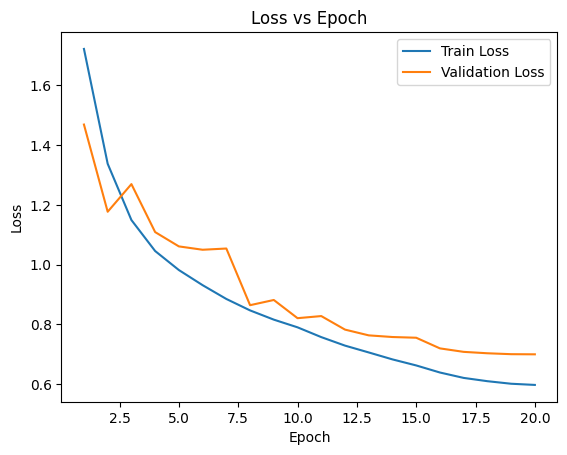

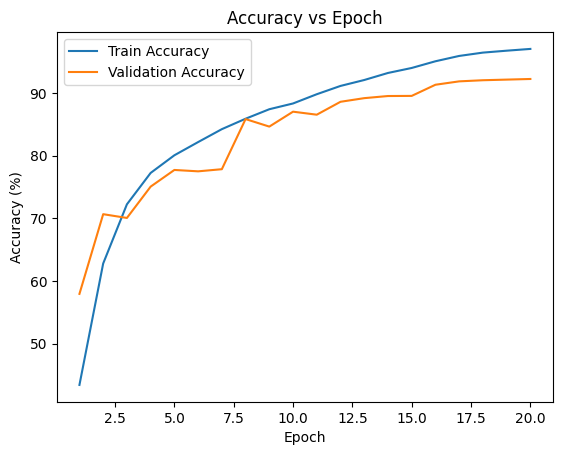

In [52]:
epochs = range(1, num_epochs + 1)

plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs Epoch')
plt.legend()
plt.savefig("loss_curve.png", dpi=300, bbox_inches="tight")
plt.show()


plt.plot(epochs, train_accs, label='Train Accuracy')
plt.plot(epochs, val_accs, label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy vs Epoch')
plt.legend()
plt.savefig("accuracy_curve.png", dpi=300, bbox_inches="tight")
plt.show()

VISUALISATION CONFUSION MATRIX

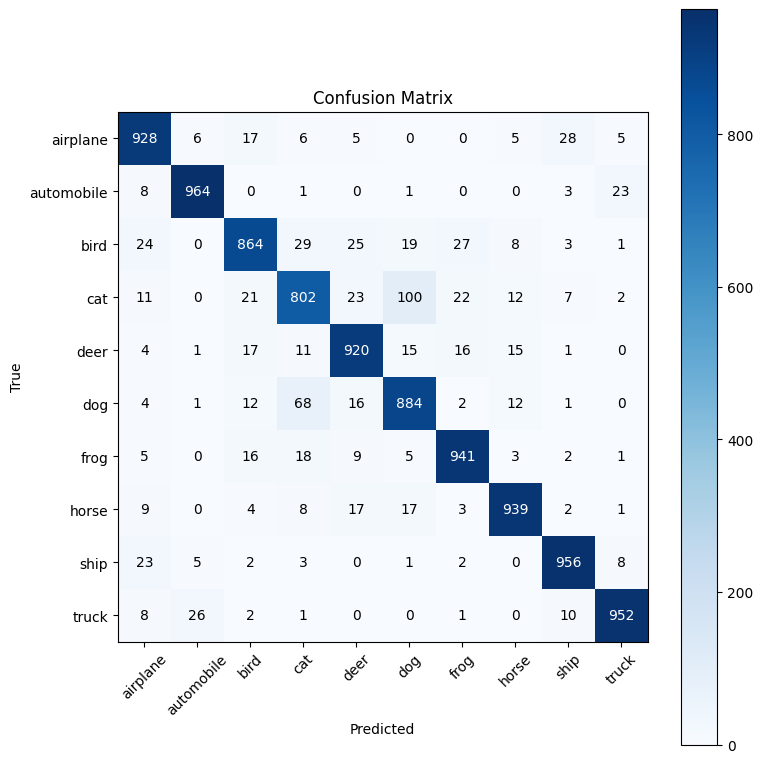

In [55]:
class_names = test_dataset.classes

plt.figure(figsize=(8,8))
plt.imshow(cm, cmap="Blues")

plt.xticks(range(10), class_names, rotation=45)
plt.yticks(range(10), class_names)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

# Add values inside each cell
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i,
            str(cm[i, j]),
            ha="center",
            va="center",
            color="white" if cm[i, j] > cm.max()/2 else "black"
        )

plt.colorbar()
plt.tight_layout()

plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()



SAVE CLASSIFICATION REPORT

In [54]:
report = classification_report(
    all_labels,
    all_predictions,
    target_names=class_names
)

with open("classification_report.txt", "w") as f:
    f.write(report)